# OSEMN Data Science Project: Baku Apartment Price Analysis

**Framework:** OSEMN = **O**btain → **S**crub → **E**xplore → **M**odel → i**N**terpret

**Problem:** Which factors influence apartment prices in Baku, and can we predict the price of an apartment from its features?

**Data sources (2 CSV files with different formats):**
- `evler_menbe1.csv` – source 1 (column names: `rayon`, `sahe`, `otaq`, ...)
- `evler_menbe2.csv` – source 2 (column names: `District`, `Area_m2`, `Rooms`, ...)

> Note: the data is synthetic (fake) and was deliberately made "dirty" (missing values, duplicates, inconsistent spelling, outliers, invalid dates) to demonstrate the Scrub stage.

In [1]:
# Libraries used in the whole project
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

---
# 1. Obtain – Collecting the Data

In this stage we load the raw data from every source and inspect it **without changing anything**.

In [2]:
# Load both sources
df1 = pd.read_csv("evler_menbe1.csv")
df2 = pd.read_csv("evler_menbe2.csv")

print("Source 1 shape:", df1.shape)
print("Source 2 shape:", df2.shape)

Source 1 shape: (615, 8)
Source 2 shape: (410, 8)


In [3]:
# First rows of source 1
df1.head()

,id,rayon,sahe,otaq,mertebe,ili,tarix,qiymet
0,1,Sebail,122.0,5.0,1.0,2012.0,2024-09-24,495899.0
1,2,Binaqadi,146.0,4.0,8.0,2006.0,2025-01-01,263853.0
2,3,Nizami,140.0,5.0,11.0,2021.0,2024-04-03,268400.0
3,4,nerimanov,50.0,2.0,6.0,2022.0,2025-01-09,114341.0
4,5,Nerimanov,153.0,5.0,3.0,2008.0,2025-07-08,362978.0


In [4]:
# First rows of source 2 (notice: different column names!)
df2.head()

,ID,District,Area_m2,Rooms,Floor,Year_Built,Date,Price_AZN
0,2001,Sebail,41.0,1.0,9.0,2021.0,2024-04-08,168050.0
1,2002,Yasamal,120.0,3.0,2.0,1988.0,2025-01-18,315266.0
2,2003,Xezer,39.0,2.0,5.0,1988.0,2024-01-20,70060.0
3,2004,Xetai,133.0,3.0,17.0,1974.0,2024-05-29,236222.0
4,2005,Yasamal,64.0,2.0,17.0,1993.0,2025-03-03,151444.0


In [5]:
# Data types and non-null counts of each source
print("=== SOURCE 1 ===")
df1.info()
print()
print("=== SOURCE 2 ===")
df2.info()

=== SOURCE 1 ===
<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       615 non-null    int64  
 1   rayon    615 non-null    str    
 2   sahe     592 non-null    float64
 3   otaq     596 non-null    float64
 4   mertebe  595 non-null    float64
 5   ili      579 non-null    float64
 6   tarix    615 non-null    str    
 7   qiymet   603 non-null    float64
dtypes: float64(5), int64(1), str(2)
memory usage: 38.6 KB

=== SOURCE 2 ===
<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          410 non-null    int64  
 1   District    410 non-null    str    
 2   Area_m2     393 non-null    float64
 3   Rooms       396 non-null    float64
 4   Floor       398 non-null    float64
 5   Year_Built  384 non-null    float64
 6   Date   

**Observations after Obtain:**
- Both sources describe the same kind of data (apartments) but use **different column names**.
- Some columns contain missing values (`NaN`), and `tarix` / `Date` is stored as text (`object`).
- Everything is still raw. Cleaning starts in the next stage.

---
# 2. Scrub – Cleaning the Data

Raw data is almost always "dirty". Steps in this stage:

1. Harmonize column names and merge the sources
2. Remove duplicate rows
3. Fix data types (dates)
4. Standardize text values (district names)
5. Handle missing values
6. Handle outliers / invalid values
7. Create new useful features

### 2.1 Harmonize column names and merge the sources

In [6]:
# Rename source 1 columns to clear English names
df1_clean = df1.rename(columns={
    "id": "id", "rayon": "district", "sahe": "area_m2", "otaq": "rooms",
    "mertebe": "floor", "ili": "year_built", "tarix": "date", "qiymet": "price_azn",
})

# Rename source 2 columns to the SAME names
df2_clean = df2.rename(columns={
    "ID": "id", "District": "district", "Area_m2": "area_m2", "Rooms": "rooms",
    "Floor": "floor", "Year_Built": "year_built", "Date": "date", "Price_AZN": "price_azn",
})

# Remember where each row came from
df1_clean["source"] = "source_1"
df2_clean["source"] = "source_2"

# Merge both sources into one DataFrame
df = pd.concat([df1_clean, df2_clean], ignore_index=True)
print("Merged shape:", df.shape)
df.head()

Merged shape: (1025, 9)


,id,district,area_m2,rooms,floor,year_built,date,price_azn,source
0,1,Sebail,122.0,5.0,1.0,2012.0,2024-09-24,495899.0,source_1
1,2,Binaqadi,146.0,4.0,8.0,2006.0,2025-01-01,263853.0,source_1
2,3,Nizami,140.0,5.0,11.0,2021.0,2024-04-03,268400.0,source_1
3,4,nerimanov,50.0,2.0,6.0,2022.0,2025-01-09,114341.0,source_1
4,5,Nerimanov,153.0,5.0,3.0,2008.0,2025-07-08,362978.0,source_1


### 2.2 Data quality report BEFORE cleaning

In [7]:
rows_before = len(df)

print("Rows before cleaning:", rows_before)
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum())

Rows before cleaning: 1025
Duplicate rows: 25

Missing values per column:
id             0
district       0
area_m2       40
rooms         33
floor         32
year_built    62
date           0
price_azn     21
source         0
dtype: int64


### 2.3 Remove duplicates

In [8]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 1000


### 2.4 Fix data types (dates)

In [9]:
# Invalid dates such as "tarix yoxdur" become NaT (missing date) because of errors="coerce"
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Invalid / missing dates:", df["date"].isnull().sum())
df["date"].describe()

Invalid / missing dates: 10


count                           990
mean     2024-10-28 08:52:21.818181
min             2024-01-01 00:00:00
25%             2024-05-25 12:00:00
50%             2024-11-01 12:00:00
75%             2025-03-22 00:00:00
max             2025-08-22 00:00:00
Name: date, dtype: object

### 2.5 Standardize text values (district names)

In [10]:
# Spelling differences BEFORE cleaning
print("Unique district values before:", df["district"].nunique())
print(sorted(df["district"].dropna().unique()))

Unique district values before: 40
['  Binaqadi ', '  Nerimanov ', '  Nesimi ', '  Nizami ', '  Sebail ', '  Xetai ', '  Xezer ', '  Yasamal ', 'BINAQADI', 'Binaqadi', 'NERIMANOV', 'NESIMI', 'NIZAMI', 'Nerimanov', 'Nesimi', 'Nizami', 'SEBAIL', 'Sebail', 'XETAI', 'XEZER', 'Xetai', 'Xezer', 'YASAMAL', 'Yasamal', 'binaqadi', 'binaqadi ', 'nerimanov', 'nerimanov ', 'nesimi', 'nesimi ', 'nizami', 'nizami ', 'sebail', 'sebail ', 'xetai', 'xetai ', 'xezer', 'xezer ', 'yasamal', 'yasamal ']


In [11]:
# Remove extra spaces and make the first letter uppercase, the rest lowercase
df["district"] = df["district"].str.strip().str.lower().str.capitalize()

print("Unique district values after:", df["district"].nunique())
print(sorted(df["district"].unique()))

Unique district values after: 8
['Binaqadi', 'Nerimanov', 'Nesimi', 'Nizami', 'Sebail', 'Xetai', 'Xezer', 'Yasamal']


### 2.6 Handle missing values

In [12]:
# Rows without a price are useless for price prediction -> drop them
df = df.dropna(subset=["price_azn"])

# Fill numeric features with the MEDIAN (robust against outliers)
for col in ["area_m2", "rooms", "floor", "year_built"]:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Missing dates are kept as NaT because date is not used in the model
print(df.isnull().sum())

id             0
district       0
area_m2        0
rooms          0
floor          0
year_built     0
date          10
price_azn      0
source         0
dtype: int64


### 2.7 Handle outliers and invalid values

In [13]:
# Look at extreme values first
df[["area_m2", "price_azn"]].describe()

,area_m2,price_azn
count,981.000000,9.810000e+02
mean,107.897044,2.632834e+05
std,116.274713,4.585828e+05
min,5.000000,-1.000000e+03
25%,66.000000,1.383100e+05
50%,105.000000,2.287160e+05
75%,139.000000,3.207070e+05
max,2500.000000,9.999999e+06


In [14]:
# Rule-based filtering (domain knowledge):
#  - a real apartment has an area between 20 and 400 m2
#  - price must be positive and realistic
before = len(df)
df = df[(df["area_m2"] >= 20) & (df["area_m2"] <= 400)]
df = df[df["price_azn"] > 0]

# Create price per m2 (useful feature and a good outlier detector)
df["price_per_m2"] = df["price_azn"] / df["area_m2"]

# Statistical filtering with the IQR rule on price per m2
q1 = df["price_per_m2"].quantile(0.25)
q3 = df["price_per_m2"].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df = df[(df["price_per_m2"] >= lower) & (df["price_per_m2"] <= upper)]

print(f"Removed {before - len(df)} outlier rows")
print(f"Allowed price per m2 range: {lower:.0f} - {upper:.0f} AZN")

Removed 29 outlier rows
Allowed price per m2 range: 413 - 4168 AZN


### 2.8 Feature engineering

In [15]:
# Building age (reference year = 2025)
df["building_age"] = 2025 - df["year_built"]

# Make sure integer-like columns have integer type
for col in ["rooms", "floor", "year_built", "building_age"]:
    df[col] = df[col].astype(int)

df = df.reset_index(drop=True)
df.head()

,id,district,area_m2,rooms,floor,year_built,date,price_azn,source,price_per_m2,building_age
0,1,Sebail,122.0,5,1,2012,2024-09-24,495899.0,source_1,4064.745902,13
1,2,Binaqadi,146.0,4,8,2006,2025-01-01,263853.0,source_1,1807.212329,19
2,3,Nizami,140.0,5,11,2021,2024-04-03,268400.0,source_1,1917.142857,4
3,4,Nerimanov,50.0,2,6,2022,2025-01-09,114341.0,source_1,2286.820000,3
4,5,Nerimanov,153.0,5,3,2008,2025-07-08,362978.0,source_1,2372.405229,17


### 2.9 Data quality report AFTER cleaning

In [16]:
print(f"Rows before cleaning : {rows_before}")
print(f"Rows after cleaning  : {len(df)}")
print(f"Rows removed         : {rows_before - len(df)}")
print()
print("Missing values (non-date columns):")
print(df.drop(columns=["date"]).isnull().sum().sum(), "missing values left")
print("Duplicate rows left:", df.duplicated().sum())

Rows before cleaning : 1025
Rows after cleaning  : 952
Rows removed         : 73

Missing values (non-date columns):
0 missing values left
Duplicate rows left: 0


---
# 3. Explore – Exploratory Data Analysis (EDA)

Goal: understand the data, find patterns and relationships **before** modeling.

In [17]:
# Statistical summary of numeric columns
df.describe().round(1)

,id,area_m2,rooms,floor,year_built,date,price_azn,price_per_m2,building_age
count,952.0,952.0,952.0,952.0,952.0,943,952.0,952.0,952.0
mean,1067.5,103.1,3.0,7.7,1996.2,2024-10-28 21:04:23.414634,238675.7,2322.5,28.8
min,1.0,30.0,1.0,1.0,1970.0,2024-01-01 00:00:00,45358.0,560.5,1.0
25%,252.8,66.0,2.0,4.0,1983.8,2024-05-27 12:00:00,137020.2,1814.8,16.0
50%,502.5,105.0,3.0,7.0,1996.0,2024-11-02 00:00:00,226063.5,2203.0,29.0
75%,2149.2,139.0,4.0,11.0,2009.0,2025-03-21 12:00:00,315137.0,2716.0,41.2
max,2400.0,179.0,6.0,24.0,2024.0,2025-08-22 00:00:00,694337.0,4163.7,55.0
std,943.9,42.7,1.5,5.2,14.9,NaN,121986.9,670.9,14.9


### 3.1 Distribution of apartment prices

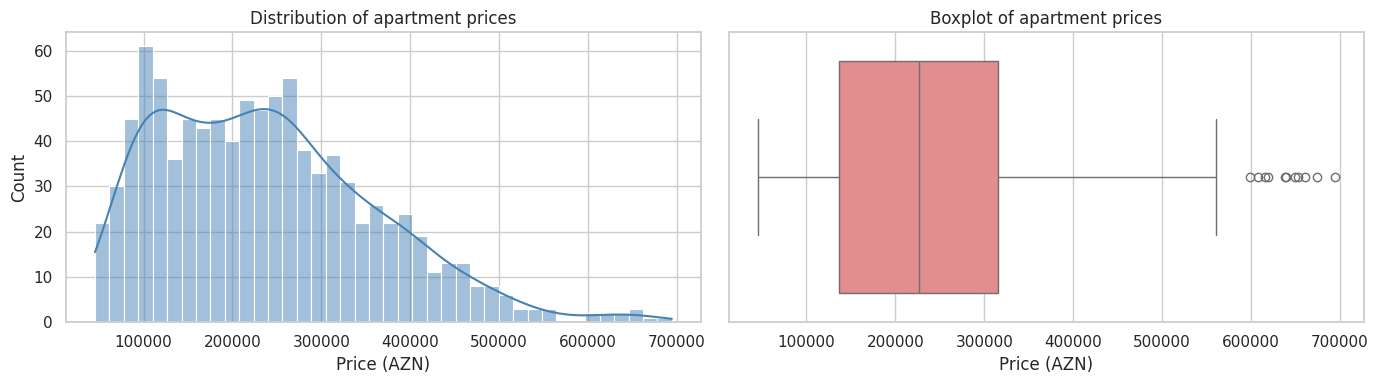

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["price_azn"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of apartment prices")
axes[0].set_xlabel("Price (AZN)")

sns.boxplot(x=df["price_azn"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot of apartment prices")
axes[1].set_xlabel("Price (AZN)")

plt.tight_layout()
plt.show()

**Observation:** The price distribution is right-skewed: most apartments are relatively cheap, and a smaller number of large or central apartments are very expensive.

### 3.2 Average price per m² by district

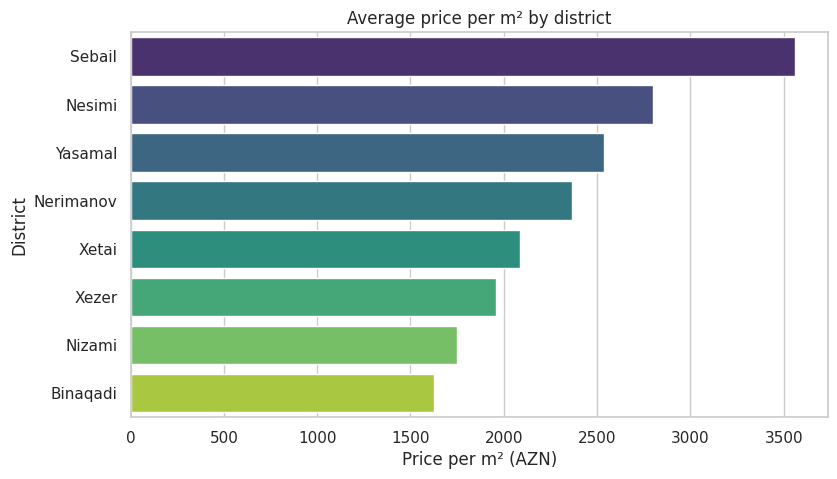

district
Sebail       3559.0
Nesimi       2798.0
Yasamal      2537.0
Nerimanov    2366.0
Xetai        2086.0
Xezer        1956.0
Nizami       1748.0
Binaqadi     1624.0
Name: price_per_m2, dtype: float64

In [19]:
district_price = (df.groupby("district")["price_per_m2"]
                    .mean()
                    .sort_values(ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(x=district_price.values, y=district_price.index, palette="viridis")
plt.title("Average price per m² by district")
plt.xlabel("Price per m² (AZN)")
plt.ylabel("District")
plt.show()

district_price.round(0)

**Observation:** Location matters a lot. Central districts (for example Sebail and Nesimi) have much higher price per m² than outer districts.

### 3.3 Area vs price

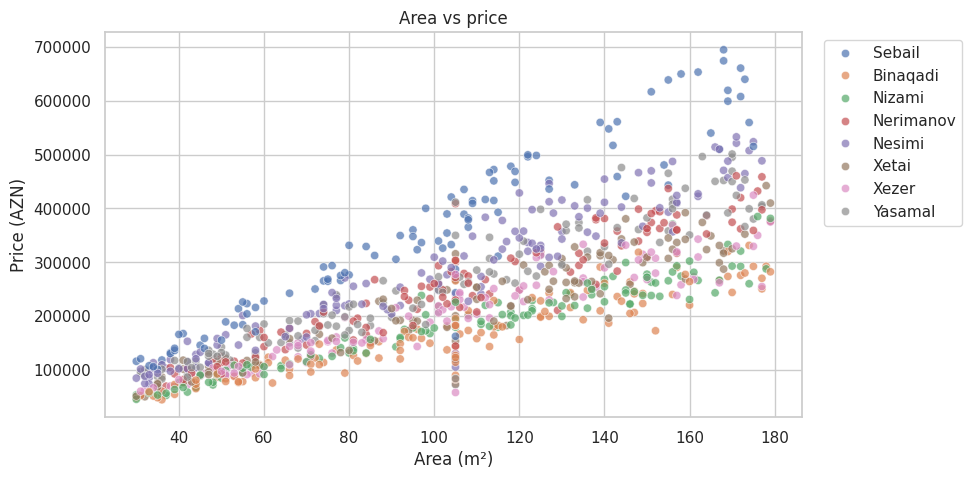

In [20]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="area_m2", y="price_azn", hue="district", alpha=0.7)
plt.title("Area vs price")
plt.xlabel("Area (m²)")
plt.ylabel("Price (AZN)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

**Observation:** There is a strong positive relationship between area and price. The spread between districts is visible as different "slopes".

### 3.4 Building age vs price per m²

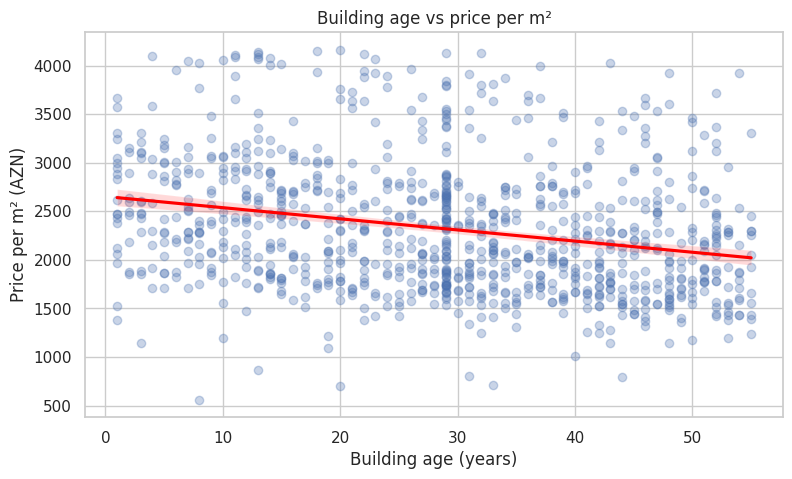

In [21]:
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x="building_age", y="price_per_m2",
            scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.title("Building age vs price per m²")
plt.xlabel("Building age (years)")
plt.ylabel("Price per m² (AZN)")
plt.show()

**Observation:** Newer buildings tend to have a higher price per m² (the trend line goes down as the building gets older).

### 3.5 Correlation matrix

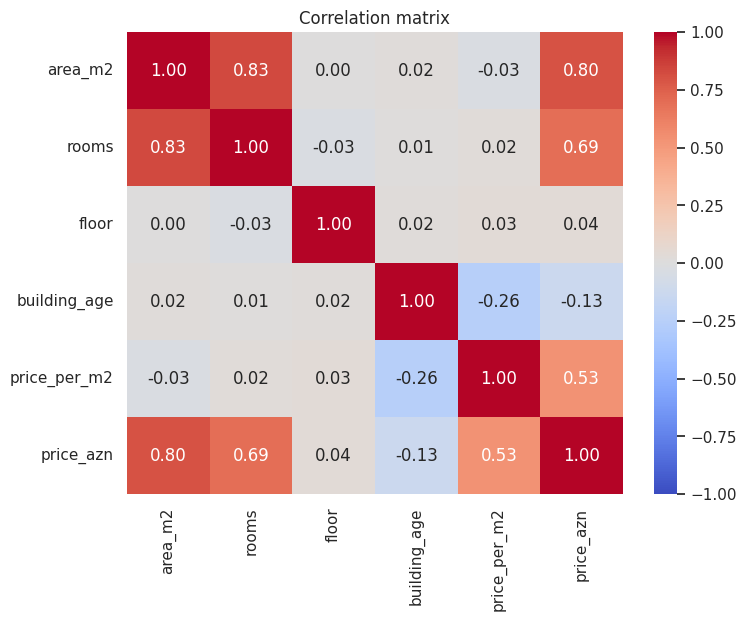

In [22]:
numeric_cols = ["area_m2", "rooms", "floor", "building_age", "price_per_m2", "price_azn"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

**Observation:** `price_azn` is strongly correlated with `area_m2` and `rooms` (rooms and area are also correlated with each other).

### 3.6 Price trend over time

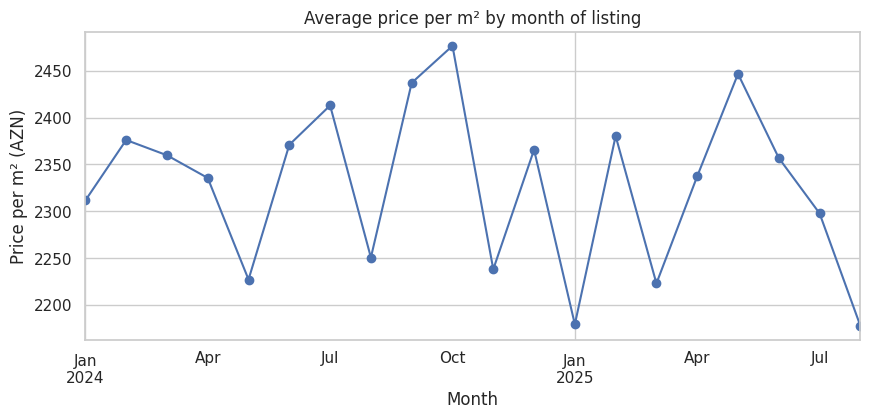

In [23]:
# Group by month (this works in both old and new pandas versions)
dated = df.dropna(subset=["date"]).copy()
dated["month"] = dated["date"].dt.to_period("M").dt.to_timestamp()
monthly = dated.groupby("month")["price_per_m2"].mean()

plt.figure(figsize=(10, 4))
monthly.plot(marker="o")
plt.title("Average price per m² by month of listing")
plt.xlabel("Month")
plt.ylabel("Price per m² (AZN)")
plt.show()

**Observation:** The monthly average fluctuates around a stable level: there is no strong time trend (which is expected because the data is synthetic).

---
# 4. Model – Building Predictive Models

**Task type:** Regression (predict a number: `price_azn`).

Steps:
1. Select features and target
2. Encode the categorical feature (`district`) with one-hot encoding
3. Split data into train (80%) and test (20%)
4. Train two models: **Linear Regression** and **Random Forest**
5. Evaluate and compare them

### 4.1 Prepare features and target

In [24]:
features = ["area_m2", "rooms", "floor", "building_age", "district"]
target = "price_azn"

# One-hot encoding for the categorical column "district"
X = pd.get_dummies(df[features], columns=["district"], drop_first=True)
y = df[target]

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (952, 11)


,area_m2,rooms,floor,building_age,district_Nerimanov,district_Nesimi,district_Nizami,district_Sebail,district_Xetai,district_Xezer,district_Yasamal
0,122.0,5,1,13,False,False,False,True,False,False,False
1,146.0,4,8,19,False,False,False,False,False,False,False
2,140.0,5,11,4,False,False,True,False,False,False,False
3,50.0,2,6,3,True,False,False,False,False,False,False
4,153.0,5,3,17,True,False,False,False,False,False,False


### 4.2 Train / test split

In [25]:
# The test set is NEVER used for training. It simulates new, unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 761
Test size : 191


### 4.3 Model 1 – Linear Regression

In [26]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_pred = lin_model.predict(X_test)

### 4.4 Model 2 – Random Forest Regressor

In [27]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

### 4.5 Evaluate and compare the models

In [28]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE (AZN)": mean_absolute_error(y_true, y_pred),
        "RMSE (AZN)": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, lin_pred),
    evaluate("Random Forest", y_test, rf_pred),
]).set_index("Model")

results.round(3)

,R2,MAE (AZN),RMSE (AZN)
Model,,,
Linear Regression,0.856,31617.754,45937.398
Random Forest,0.921,24468.345,34059.400


In [29]:
# 5-fold cross-validation: a more reliable estimate than a single split
for name, model in [("Linear Regression", lin_model), ("Random Forest", rf_model)]:
    scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(f"{name:18s} CV R2: mean = {scores.mean():.3f}, std = {scores.std():.3f}")

Linear Regression  CV R2: mean = 0.890, std = 0.015


Random Forest      CV R2: mean = 0.931, std = 0.012


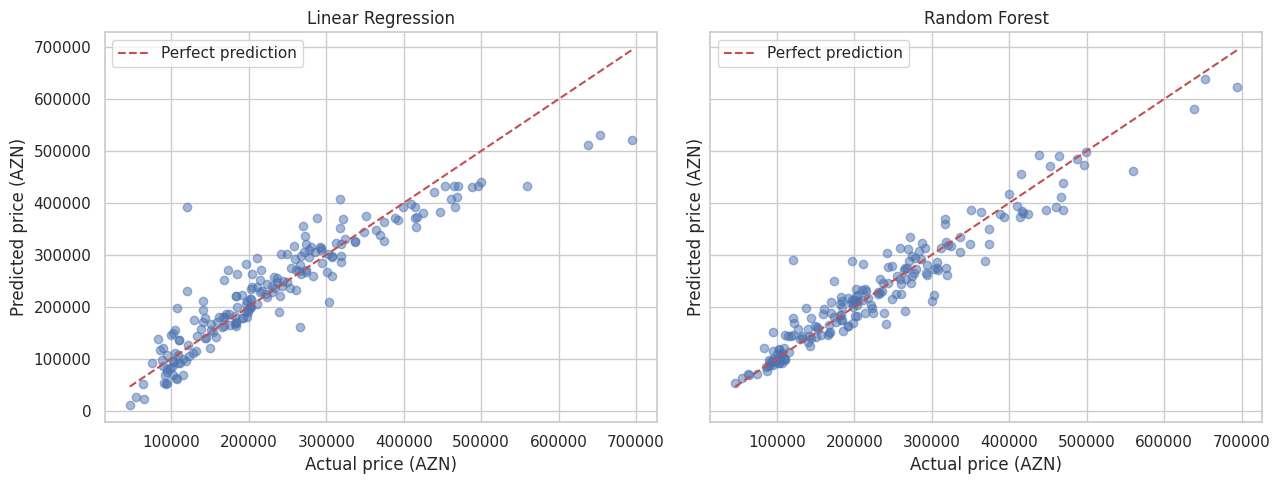

In [30]:
# Actual vs predicted values on the test set
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, pred, title in [(axes[0], lin_pred, "Linear Regression"),
                        (axes[1], rf_pred, "Random Forest")]:
    ax.scatter(y_test, pred, alpha=0.5)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "r--", label="Perfect prediction")
    ax.set_title(title)
    ax.set_xlabel("Actual price (AZN)")
    ax.set_ylabel("Predicted price (AZN)")
    ax.legend()

plt.tight_layout()
plt.show()

---
# 5. iNterpret – Interpreting the Results

Now we translate numbers into real-world meaning.

### 5.1 Which model is better?

In [31]:
best_model_name = results["R2"].idxmax()
best_r2 = results["R2"].max()
best_mae = results.loc[best_model_name, "MAE (AZN)"]

print(f"Best model : {best_model_name}")
print(f"R2         : {best_r2:.3f}  -> the model explains {best_r2*100:.1f}% of the variation in prices")
print(f"MAE        : {best_mae:,.0f} AZN -> on average the prediction is off by this amount")

Best model : Random Forest
R2         : 0.921  -> the model explains 92.1% of the variation in prices
MAE        : 24,468 AZN -> on average the prediction is off by this amount


### 5.2 Which factors influence the price the most?

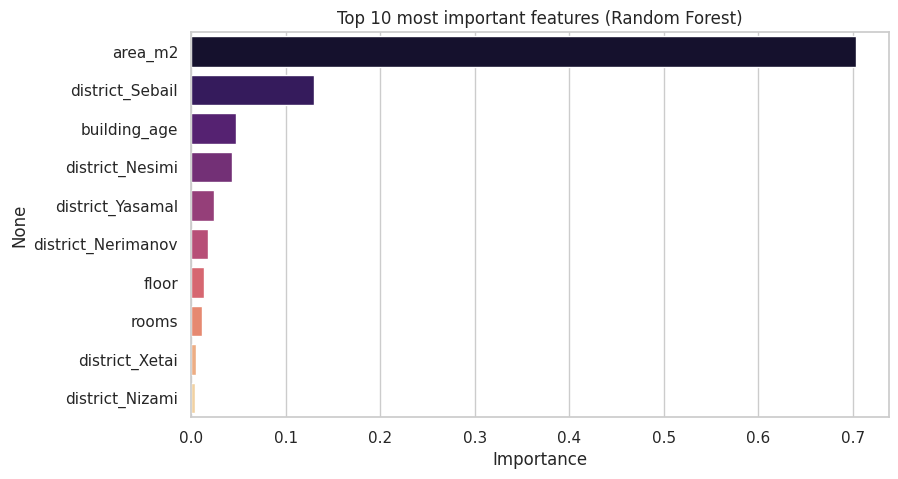

area_m2               0.703
district_Sebail       0.130
building_age          0.047
district_Nesimi       0.043
district_Yasamal      0.024
district_Nerimanov    0.018
floor                 0.013
rooms                 0.011
district_Xetai        0.005
district_Nizami       0.004
dtype: float64

In [32]:
# Random Forest feature importance
importance = (pd.Series(rf_model.feature_importances_, index=X.columns)
                .sort_values(ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(x=importance.values[:10], y=importance.index[:10], palette="magma")
plt.title("Top 10 most important features (Random Forest)")
plt.xlabel("Importance")
plt.show()

importance.head(10).round(3)

In [33]:
# Linear Regression coefficients: the effect of each feature on price (in AZN)
coefs = pd.Series(lin_model.coef_, index=X.columns).sort_values(ascending=False)
coefs.round(0)

district_Sebail       199469.0
district_Nesimi       118276.0
district_Yasamal       91918.0
district_Nerimanov     74004.0
district_Xetai         51512.0
district_Xezer         35713.0
district_Nizami        11583.0
rooms                   7627.0
area_m2                 2087.0
floor                    139.0
building_age           -1199.0
dtype: float64

**How to read the coefficients:**
- `area_m2`: each additional m² increases the price by the coefficient value (AZN), all other features being equal.
- `building_age`: a negative coefficient means each extra year of building age lowers the price.
- `district_*`: the price difference compared to the reference district (the one removed by `drop_first=True`).

### 5.3 Example prediction for a new apartment

In [34]:
# A new apartment: 90 m2, 3 rooms, 7th floor, 5 years old, in Nesimi
new_apartment = {"area_m2": 90, "rooms": 3, "floor": 7, "building_age": 5, "district": "Nesimi"}

new_df = pd.get_dummies(pd.DataFrame([new_apartment]), columns=["district"])
new_df = new_df.reindex(columns=X.columns, fill_value=0)   # match training columns

price_pred = rf_model.predict(new_df)[0]
print(f"Predicted price: {price_pred:,.0f} AZN")

Predicted price: 250,987 AZN


### 5.4 Conclusions

1. **Area** and **district** are the strongest drivers of apartment price. Location can change the price per m² by a large margin.
2. **Building age** has a negative effect: newer buildings are more expensive.
3. The Random Forest model captures non-linear relationships and usually gives better accuracy than Linear Regression, while Linear Regression is easier to explain.
4. The model can be used to estimate a fair price for a new listing or to spot listings priced far from the predicted value.

### 5.5 Limitations

- The data is **synthetic**, so real-world patterns (view, renovation, metro distance, etc.) are missing.
- Only 5 features were used; more features would improve accuracy.
- Median imputation is simple; more advanced imputation could be tested.
- No hyperparameter tuning was performed (e.g. `GridSearchCV`).

### 5.6 Recommended next steps

- Collect real data (e.g. from listing sites through an API or scraping).
- Add more features (distance to metro, renovation status, etc.).
- Try Gradient Boosting (XGBoost, LightGBM) and tune hyperparameters.
- Build a small web app that predicts the price from user input.